<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_7_1_Computer_Vision_with_PyTorch_Excercises_Dmytro_Koval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises. Solution


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

###Відповідь:


1. **Автомобільна промисловість**  
   - Системи автономного водіння, асистенти водія, розпізнавання дорожніх знаків та пішоходів.

2. **Медицина**  
   - Аналіз медичних зображень: рентген, МРТ, КТ; виявлення пухлин, діагностика захворювань.

3. **Виробництво та робототехніка**  
   - Контроль якості продукції, виявлення дефектів, навігація роботів на заводах.


## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

### Відповідь:

1. **На перших шарах CNN мережа виявляє прості ознаки**  
   - Лінії, кути, краї, текстури.  
   - Ці фільтри реагують на базові форми.

2. **На середніх шарах з’являються складніші патерни**  
   - Мережа розпізнає частини об’єктів: очі, текстури шерсті, форми предметів.  
   - Активності стають більш структурними та інформативними.

3. **На останніх шарах CNN концентрується на високорівневих ознаках**  
   - Мережа розуміє, до якого класу належить об’єкт.  
   - Активуються ті фільтри, які найбільше відповідають певним категоріям, а фінальні вектори ознак передаються у шари для класифікації.


## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [1]:
from torchvision import datasets, transforms

# Transform images to tensors
transform = transforms.ToTensor()

# Load MNIST train and test datasets
train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# Print number of samples
print("Number of images in train set:", len(train_data))
print("Number of images in test set:", len(test_data))

# Check the shape of 1 image
image, label = train_data[0]
print("Image shape:", image.shape)

# Print all classes
print("Classes:", train_data.classes)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

Number of images in train set: 60000
Number of images in test set: 10000
Image shape: torch.Size([1, 28, 28])
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

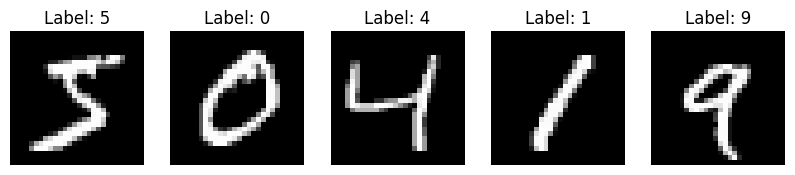

In [2]:
import matplotlib.pyplot as plt

# Transform images to tensors
transform = transforms.ToTensor()

# Load MNIST train dataset
train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)

# Plot 5 sample images
plt.figure(figsize=(10, 2))

for i in range(5):
    image, label = train_data[i]

    # Convert tensor image to numpy for vis
    image = image.squeeze().numpy()

    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()


## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [3]:
import torch
from torch.utils.data import DataLoader

# Transform images to tensors
transform = transforms.ToTensor()

# Load MNIST train/test datasets
train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# Create DataLoaders, batch_size=32
train_loader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)

# Get 1 batch from train_loader
images, labels = next(iter(train_loader))

print("Batch images shape:", images.shape)   # [32, 1, 28, 28]
print("Batch labels shape:", labels.shape)   # [32]


Batch images shape: torch.Size([32, 1, 28, 28])
Batch labels shape: torch.Size([32])


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [4]:
import torch
from torch import nn

class MNISTModelV2(nn.Module):
    """
    TinyVGG-style CNN architecture for MNIST.
    Based on: https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_channels: int, hidden_units: int, output_shape: int):
        super().__init__()

        # 1st convolutional block
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_channels,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),  # "same" padding for 28x28 -> 28x28
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 28x28 -> 14x14
        )

        # 2nd convolutional block
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 14x14 -> 7x7
        )

        # Classifier block
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # After two MaxPool(2): 28x28 -> 14x14 -> 7x7
            nn.Linear(in_features=hidden_units * 7 * 7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_2 = MNISTModelV2(input_channels=1, hidden_units=10, output_shape=10).to(device)
model_2



MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [6]:
import time
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Device list: CPU and GPU
devices = ["cpu"]
if torch.cuda.is_available():
    devices.append("cuda")

print("Available devices:", devices)

# Transform: images to tensors
transform = transforms.ToTensor()

# Load MNIST train dataset
train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)

# Create DataLoader
batch_size = 32
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

# Training settings
num_epochs = 5
input_channels = 1
hidden_units = 10
output_shape = 10

# Function to train model on a given device and measure time
def train_on_device(device: str):
    print(f"\n=== Training on {device.upper()} ===")

    model = MNISTModelV2(
        input_channels=input_channels,
        hidden_units=hidden_units,
        output_shape=output_shape
    ).to(device)  # keep model on its device

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            y_pred = model(images)
            loss = loss_fn(y_pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}] | Avg train loss: {epoch_loss / len(train_loader):.4f}")

    total_time = time.time() - start_time
    print(f"Total training time on {device.upper()}: {total_time:.2f} seconds")

    return model, total_time


# Train and keep models on their device
times = {}
trained_models = {}

for dev in devices:
    model, train_time = train_on_device(dev)
    trained_models[dev] = model    # keep model on its device
    times[dev] = train_time

# Print summary
print("\n=== Summary ===")
for dev, t in times.items():
    print(f"{dev.upper()}: {t:.2f} seconds")

# GPU model remains on CUDA:
gpu_model = trained_models.get("cuda", None)
if gpu_model is not None:
    print("GPU model is stored on:", next(gpu_model.parameters()).device)


Available devices: ['cpu', 'cuda']

=== Training on CPU ===
Epoch [1/5] | Avg train loss: 0.2211
Epoch [2/5] | Avg train loss: 0.0712
Epoch [3/5] | Avg train loss: 0.0540
Epoch [4/5] | Avg train loss: 0.0446
Epoch [5/5] | Avg train loss: 0.0373
Total training time on CPU: 237.79 seconds

=== Training on CUDA ===
Epoch [1/5] | Avg train loss: 0.2259
Epoch [2/5] | Avg train loss: 0.0746
Epoch [3/5] | Avg train loss: 0.0562
Epoch [4/5] | Avg train loss: 0.0450
Epoch [5/5] | Avg train loss: 0.0384
Total training time on CUDA: 62.36 seconds

=== Summary ===
CPU: 237.79 seconds
CUDA: 62.36 seconds
GPU model is stored on: cuda:0


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

Using device for inference: cuda:0


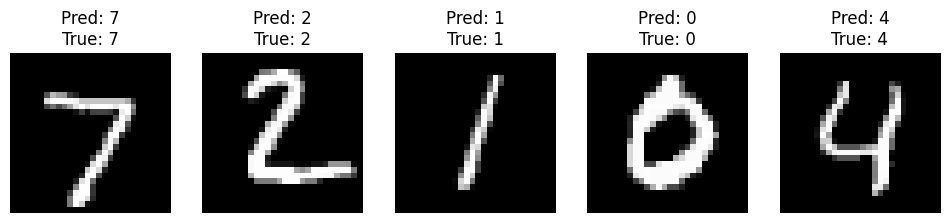

In [7]:
# import matplotlib.pyplot as plt
# import torch

# Choose the trained model - GPU first
model = trained_models.get("cuda", trained_models.get("cpu"))
device = next(model.parameters()).device
print("Using device for inference:", device)

# Make sure the model is in evaluation mode !
model.eval()

# Get 5 samples from the test dataset
samples = []
for i in range(5):
    image, label = test_data[i]
    samples.append((image, label))

# Visualize 5 predictions
plt.figure(figsize=(12, 3))

for idx, (image, label) in enumerate(samples):
    # Prepare image for prediction
    img = image.unsqueeze(0).to(device)   # should be shape: (1, 1, 28, 28)

    # Forward pass
    with torch.inference_mode():
        pred_logits = model(img)
        pred_label = torch.argmax(pred_logits, dim=1).item()

    # Convert image to numpy for vis
    img_np = image.squeeze().numpy()

    # Plot
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img_np, cmap="gray")
    plt.title(f"Pred: {pred_label}\nTrue: {label}")
    plt.axis("off")

plt.show()


In [8]:
# import torch
# from torch import nn

# Select the trained model: prefer GPU version if available
model = trained_models.get("cuda", trained_models.get("cpu"))

# Detect the device where the model is stored
device = next(model.parameters()).device
print("Evaluating on device:", device)

# Set model to evaluation mode
model.eval()

correct = 0
total = 0

# Disable gradients
with torch.inference_mode():
    for images, labels in test_loader:
        # Move batch to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Predicted class = index of max logit
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Compute accuracy
accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")


Evaluating on device: cuda:0
Test Accuracy: 98.86%


## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

Using device for confusion matrix: cuda:0


<Figure size 800x800 with 0 Axes>

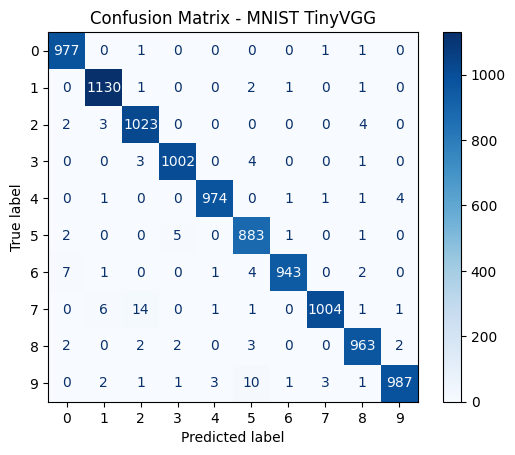

In [9]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Select trained model: prefer GPU model if available
model = trained_models.get("cuda", trained_models.get("cpu"))
device = next(model.parameters()).device
print("Using device for confusion matrix:", device)

model.eval()

all_preds = []
all_labels = []

# Collect all predictions and true labels
with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(range(10)))

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - MNIST TinyVGG")
plt.show()


## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

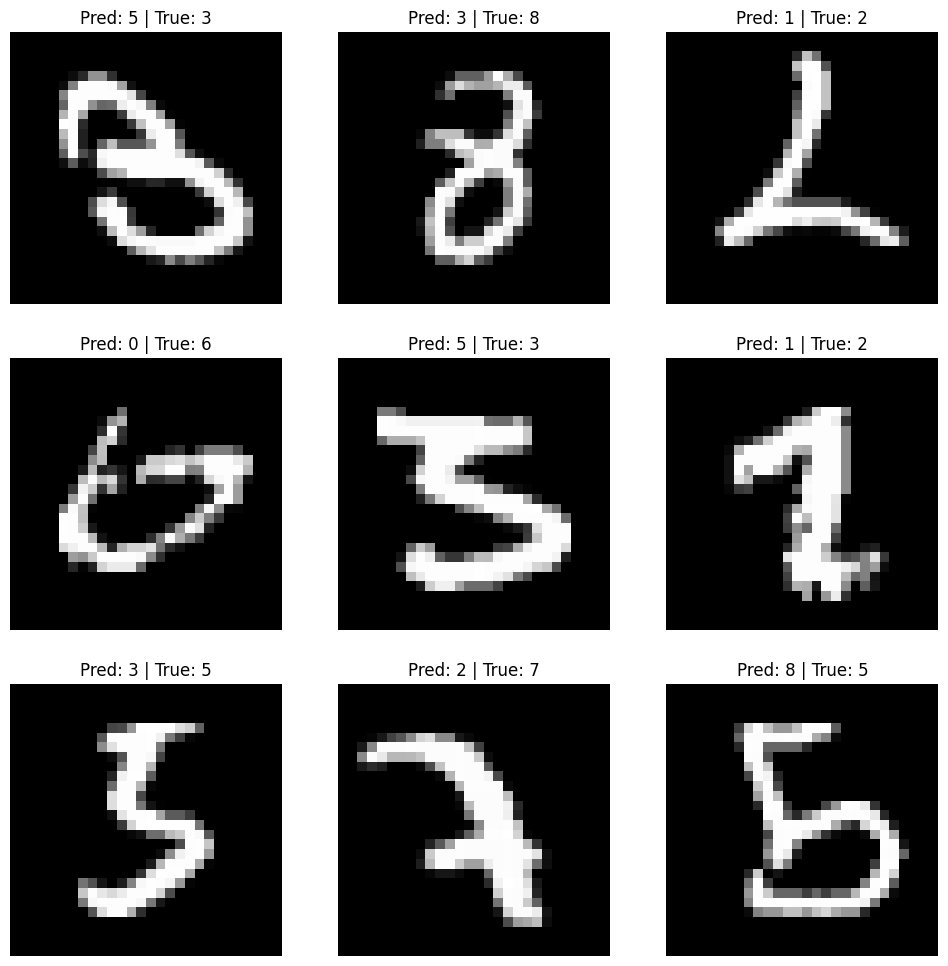

In [10]:
import matplotlib.pyplot as plt
import torch

# Select trained model -  GPU first
model = trained_models.get("cuda", trained_models.get("cpu"))
device = next(model.parameters()).device

model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

# Collect misclassified samples
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        # Find incorrect indices
        incorrect = preds != labels

        for img, pred, true in zip(images[incorrect], preds[incorrect], labels[incorrect]):
            wrong_images.append(img.cpu())
            wrong_preds.append(pred.item())
            wrong_labels.append(true.item())

        # Stop when we collected 9 samples
        if len(wrong_images) >= 9:
            break

# Plot 9 missed samples
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(wrong_images[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {wrong_preds[i]} | True: {wrong_labels[i]}")
    plt.axis("off")

plt.show()


### Висновок

Після перегляду помилкових прикладів видно, що значна кількість помилок моделі пов’язані, в першу чергу,з неоднозначністю рукописних цифр у даних.

У багатьох прикладах цифри написані:

- нерозбірливо або дуже нерівно,
- із пересічними або зайвими штрихами,
- у стилі, який може виглядати як інша цифра навіть для людини.

Наприклад:
- 9 легко сплутати з 4 або 8,
- 6 інколи схожий на 0, і навпаки.
- 8 може бути схожа на 3.

Оскільки модель вже показує близько ~98% accuracy, більшість помилок — це випадки, де навіть людині складно однозначно визначити правильну мітку. Тому це можливо більше помилка даних (якість рукописних цифр), а не недоліки моделі.


## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [11]:
import torch
from torch import nn

# Create random tensor of shape [1, 3, 64, 64]
x = torch.randn(1, 3, 64, 64)

print("Input shape:", x.shape)

# Test different kernel sizes
kernel_sizes = [1, 3, 5, 7, 9]

for k in kernel_sizes:
    conv = nn.Conv2d(in_channels=3,
                     out_channels=8,
                     kernel_size=k,
                     stride=1,
                     padding=0)   # try padding = kernel_size//2

    out = conv(x)
    print(f"Kernel size = {k} -> Output shape: {out.shape}")


Input shape: torch.Size([1, 3, 64, 64])
Kernel size = 1 -> Output shape: torch.Size([1, 8, 64, 64])
Kernel size = 3 -> Output shape: torch.Size([1, 8, 62, 62])
Kernel size = 5 -> Output shape: torch.Size([1, 8, 60, 60])
Kernel size = 7 -> Output shape: torch.Size([1, 8, 58, 58])
Kernel size = 9 -> Output shape: torch.Size([1, 8, 56, 56])


### Висновок

Під час збільшення параметра `kernel_size` розмір вихідної карти ознак стає меншим, якщо `padding=0`.  
Це тому, що велике ядро охоплює більшу область зображення, і відповідно менше  позицій доступні для його переміщення.

- Невелике значення kernel (1, 3):
  Вихідна карта зменшується незначно.

- Велике значення kernel (5, 7, 9):
  Вихідна карта помітно зменшується, оскільки ядро забирає більше простору по краям.


Параметр `padding` додає штучні пікселі навколо зображення (зазвичай нулі), щоб компенсувати зменшення розміру після згортки.

- Якщо `padding = 0`:
  Розмір вихідної карти завжди зменшується зі збільшенням `kernel_size`.

- Якщо `padding = "same"` або вибране вручну (наприклад, `padding = kernel_size // 2`):
  Розмір вихідної карти залишається таким самим, незалежно від `kernel_size`.  
  Тобто навіть велике ядро не зменшує просторові розміри.


Таким чином padding дозволяє контролювати, чи будуть просторові розміри зменшуватися при згортці, чи залишаться незмінними.
